In [36]:
%matplotlib inline

In [48]:
import tensorflow as tf

def create_data(w=0.5,b=0.1,n=100):
    X = tf.random.uniform(shape=(n,))
    noise = tf.random.normal(shape=(n, ),mean=0,stddev=0.02)
    return X, X * w + b + noise

In [69]:
import  matplotlib.pyplot as plt
X,y = create_data(n=1000)


(array([ 97.,  94.,  86., 123., 103., 103., 104., 102., 104.,  84.]),
 array([0.00542212, 0.10486209, 0.20430207, 0.30374205, 0.40318203,
        0.50262201, 0.60206199, 0.70150197, 0.80094194, 0.90038192,
        0.9998219 ]),
 <BarContainer object of 10 artists>)

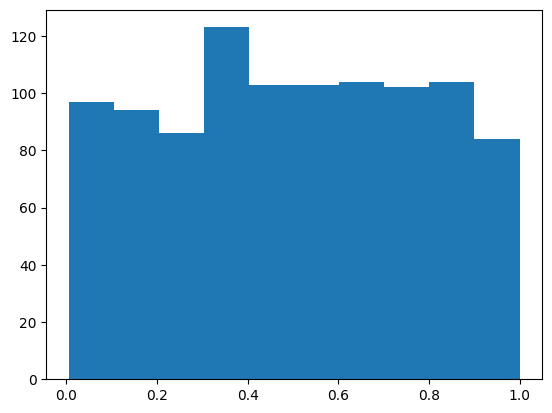

In [55]:
plt.hist(X.numpy())

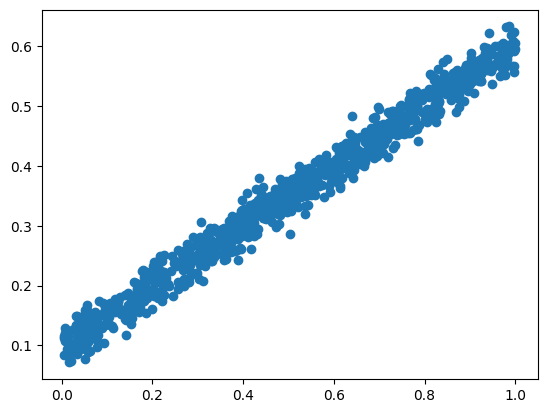

In [56]:
plt.scatter(X,y)

In [79]:
w_guess = tf.Variable(0.0)
b_guess = tf.Variable(0.0)

In [80]:
def predict(X):
    return w_guess * X + b_guess

In [81]:
predict(0.4)

<tf.Tensor: shape=(), dtype=float32, numpy=0.0>

In [82]:
def loss(y,y_predict):
    return tf.reduce_mean(tf.square(y - y_predict))

In [88]:
# training
L = 0.001
steps = 100000

for step in range(steps):
    with tf.GradientTape() as tp:
        y_pred = X * w_guess + b_guess
        mse = loss(y, y_pred)

    gradients = tp.gradient(mse, [w_guess, b_guess])

    w_guess.assign_sub(L * gradients[0])
    b_guess.assign_sub(L * gradients[1])

    if step % 500 == 0:
        print(f"Step = {step}, w = {w_guess.numpy()}, b = {b_guess.numpy()}, loss = {mse.numpy()}")

Step = 0, w = 0.4257795512676239, b = 0.1392790675163269, loss = 0.0008704756619408727
Step = 500, w = 0.4304177165031433, b = 0.13679279386997223, loss = 0.0008150573703460395
Step = 1000, w = 0.43476617336273193, b = 0.1344611793756485, loss = 0.0007663404103368521
Step = 1500, w = 0.4388430714607239, b = 0.13227494060993195, loss = 0.0007235148223116994
Step = 2000, w = 0.44266560673713684, b = 0.1302250474691391, loss = 0.0006858666893094778
Step = 2500, w = 0.44624951481819153, b = 0.1283031404018402, loss = 0.000652772025205195
Step = 3000, w = 0.4496098756790161, b = 0.1265011727809906, loss = 0.0006236779736354947
Step = 3500, w = 0.4527604579925537, b = 0.12481162697076797, loss = 0.0005981026333756745
Step = 4000, w = 0.4557143747806549, b = 0.12322750687599182, loss = 0.000575619749724865
Step = 4500, w = 0.4584839940071106, b = 0.12174225598573685, loss = 0.000555855396669358
Step = 5000, w = 0.4610808193683624, b = 0.1203496977686882, loss = 0.0005384806427173316
Step = 55

KeyboardInterrupt: 